<a href="https://www.kaggle.com/code/sonawanelalitsunil/title-emergency-healthcare-call-trends-ml-56?scriptVersionId=228236643" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/healthcare-call-data-analysis-duringemergencytimes/daily_and_month_call_report.csv


## Title: Emergency Healthcare Call Trends

## Description:
This analysis explores patterns in healthcare-related calls during emergency periods. It examines call volumes, types of inquiries, and service requests such as doctor consultations, health information, and ambulance assistance. The study applies machine learning models to identify trends and predict call demand, aiding in better resource allocation and emergency response planning.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/healthcare-call-data-analysis-duringemergencytimes/daily_and_month_call_report.csv')

In [3]:
df.head()

,Year,Month,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
0,2025,Feb,155200,98964,3777,5773,3706,42980
1,2025,Jan,130982,87815,3217,4179,3178,32593
2,2024,Dec,133725,86832,3634,3735,3035,36489
3,2024,Nov,153698,93710,3010,4421,4133,48424
4,2024,Oct,214604,108207,6307,5792,8885,80804


In [4]:
df.tail()

,Year,Month,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
102,2016,Aug,142400,112831,12184,980,340,16065
103,2016,July,145061,116686,11831,922,404,15218
104,2016,June,186433,152580,14887,856,473,17637
105,2016,May,166635,137326,12118,925,439,15827
106,2016,Apr,51432,43885,3175,220,77,4075


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Year                                       107 non-null    int64 
 1   Month                                      107 non-null    object
 2   Total Number of Calls                      107 non-null    int64 
 3   Total Number of Doctors Consultancy        107 non-null    int64 
 4   Number of Total Health Information         107 non-null    int64 
 5   Number of Total Ambulance Information      107 non-null    int64 
 6   Number of Total Complaints                 107 non-null    int64 
 7   Number of Calls To Know About The Service  107 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 6.8+ KB


In [6]:
df.isnull().sum()

Year                                         0
Month                                        0
Total Number of Calls                        0
Total Number of Doctors Consultancy          0
Number of Total Health Information           0
Number of Total Ambulance Information        0
Number of Total Complaints                   0
Number of Calls To Know About The Service    0
dtype: int64

In [7]:
df.describe()

,Year,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
count,107.000000,1.070000e+02,1.070000e+02,107.000000,107.000000,107.000000,107.000000
mean,2020.205607,2.340316e+05,1.544553e+05,15714.728972,9240.317757,6924.457944,47509.102804
std,2.601662,3.697001e+05,2.681351e+05,23104.165341,15330.680874,10484.201602,61227.797516
min,2016.000000,5.143200e+04,3.816200e+04,3010.000000,220.000000,77.000000,4075.000000
25%,2018.000000,9.918850e+04,6.081800e+04,6858.000000,836.000000,697.000000,18536.500000
50%,2020.000000,1.424000e+05,9.489300e+04,10841.000000,4734.000000,4133.000000,28895.000000
75%,2022.000000,2.025520e+05,1.215265e+05,13291.000000,8658.500000,8262.000000,45822.500000
max,2025.000000,2.329457e+06,1.703100e+06,173306.000000,91751.000000,59760.000000,342434.000000


In [8]:
df.dtypes

Year                                          int64
Month                                        object
Total Number of Calls                         int64
Total Number of Doctors Consultancy           int64
Number of Total Health Information            int64
Number of Total Ambulance Information         int64
Number of Total Complaints                    int64
Number of Calls To Know About The Service     int64
dtype: object

In [9]:
df.corr

<bound method DataFrame.corr of      Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0    2025   Feb                 155200                                98964   
1    2025   Jan                 130982                                87815   
2    2024   Dec                 133725                                86832   
3    2024   Nov                 153698                                93710   
4    2024   Oct                 214604                               108207   
..    ...   ...                    ...                                  ...   
102  2016   Aug                 142400                               112831   
103  2016  July                 145061                               116686   
104  2016  June                 186433                               152580   
105  2016   May                 166635                               137326   
106  2016   Apr                  51432                                43885   

     Number of Tota

In [10]:
df.shape

(107, 8)

In [11]:
df.columns

Index(['Year', 'Month', 'Total Number of Calls',
       'Total Number of Doctors Consultancy',
       'Number of Total Health Information',
       'Number of Total Ambulance Information', 'Number of Total Complaints',
       'Number of Calls To Know About The Service'],
      dtype='object')

## Data visualizations

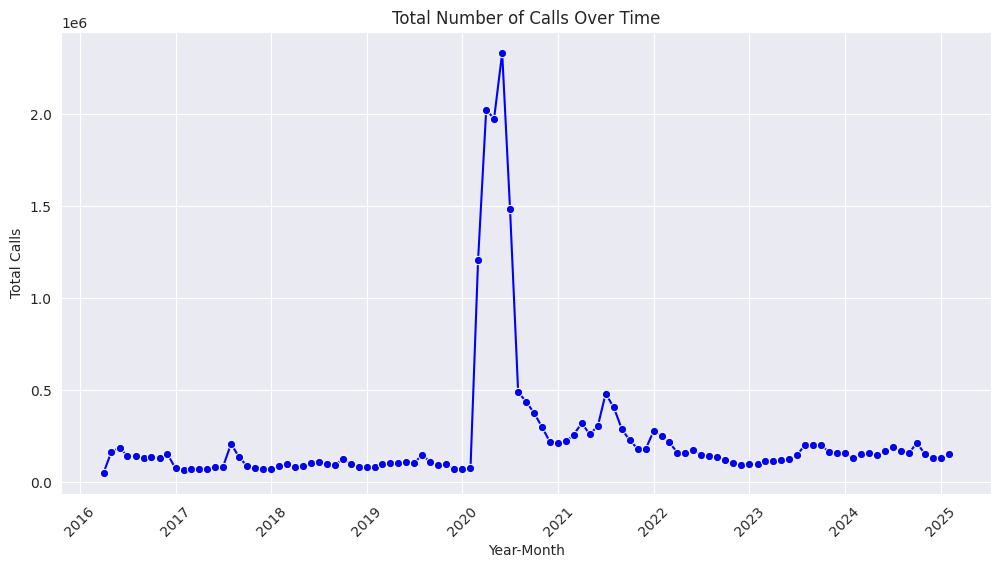

In [12]:
# Ensure 'Month' is converted properly
df["Month"] = df["Month"].astype(str).str.zfill(2)  # Ensures '1' -> '01', '2' -> '02'

# Create 'Date' column
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"], errors="coerce")

# Drop any NaT values if conversion fails
df = df.dropna(subset=["Date"])


# Set the style
sns.set_style("darkgrid")

# Line Chart - Total Calls Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Date", y="Total Number of Calls", marker="o", color="b")
plt.title("Total Number of Calls Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Total Calls")
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

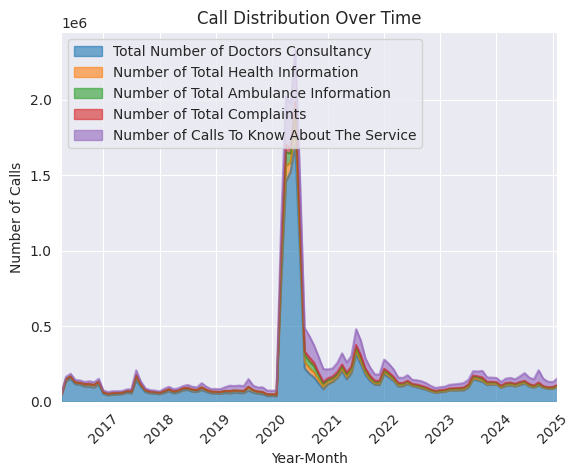

In [13]:
# Stacked Area Chart - Contribution of Different Call Types
plt.figure(figsize=(12, 6))
df.set_index("Date")[['Total Number of Doctors Consultancy', 
                        'Number of Total Health Information', 
                        'Number of Total Ambulance Information', 
                        'Number of Total Complaints', 
                        'Number of Calls To Know About The Service']].plot.area(alpha=0.6)
plt.title("Call Distribution Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.show()

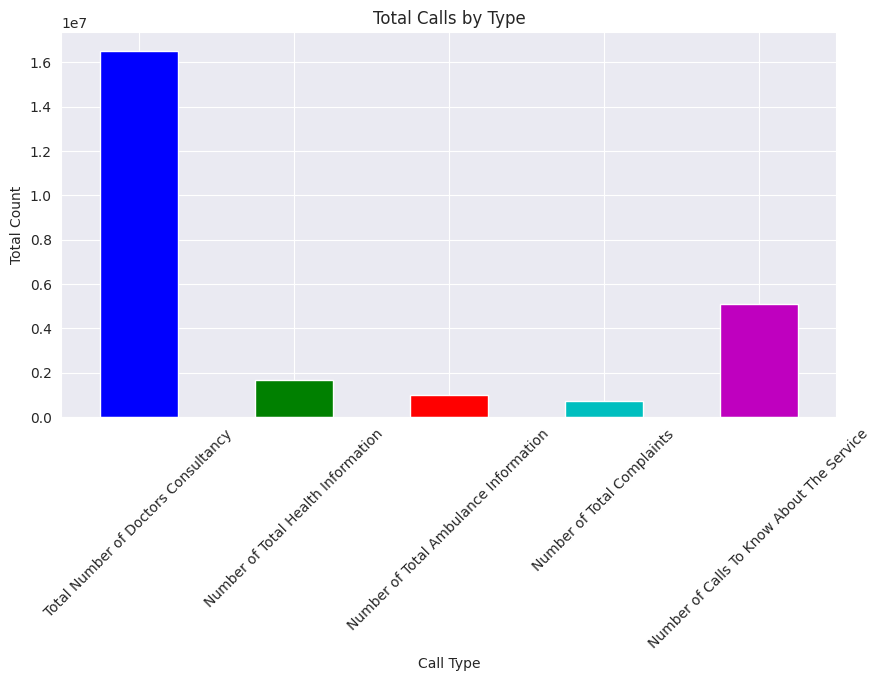

In [14]:
# Bar Chart - Total Calls by Type
plt.figure(figsize=(10, 5))
df[['Total Number of Doctors Consultancy', 
    'Number of Total Health Information', 
    'Number of Total Ambulance Information', 
    'Number of Total Complaints', 
    'Number of Calls To Know About The Service']].sum().plot(kind="bar", color=["b", "g", "r", "c", "m"])
plt.title("Total Calls by Type")
plt.xlabel("Call Type")
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.show()

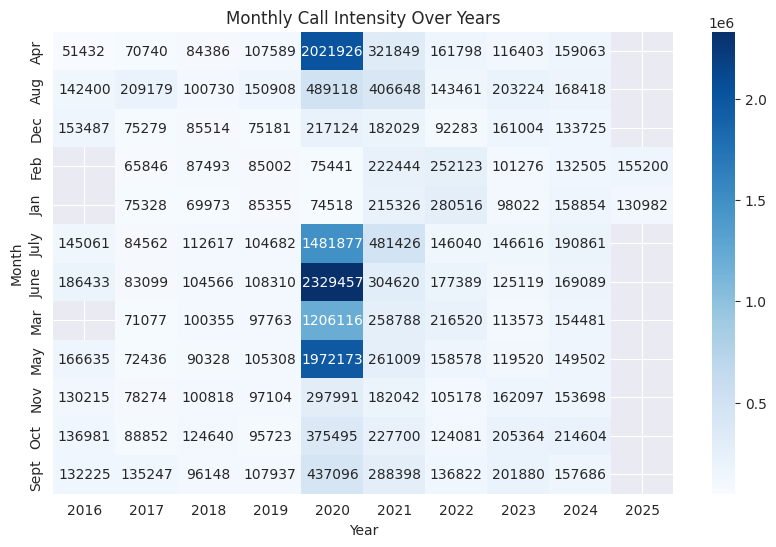

In [15]:
# Heatmap - Monthly Call Intensity
df_pivot = df.pivot_table(index='Month', columns='Year', values='Total Number of Calls', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(df_pivot, cmap="Blues", annot=True, fmt=".0f")
plt.title("Monthly Call Intensity Over Years")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

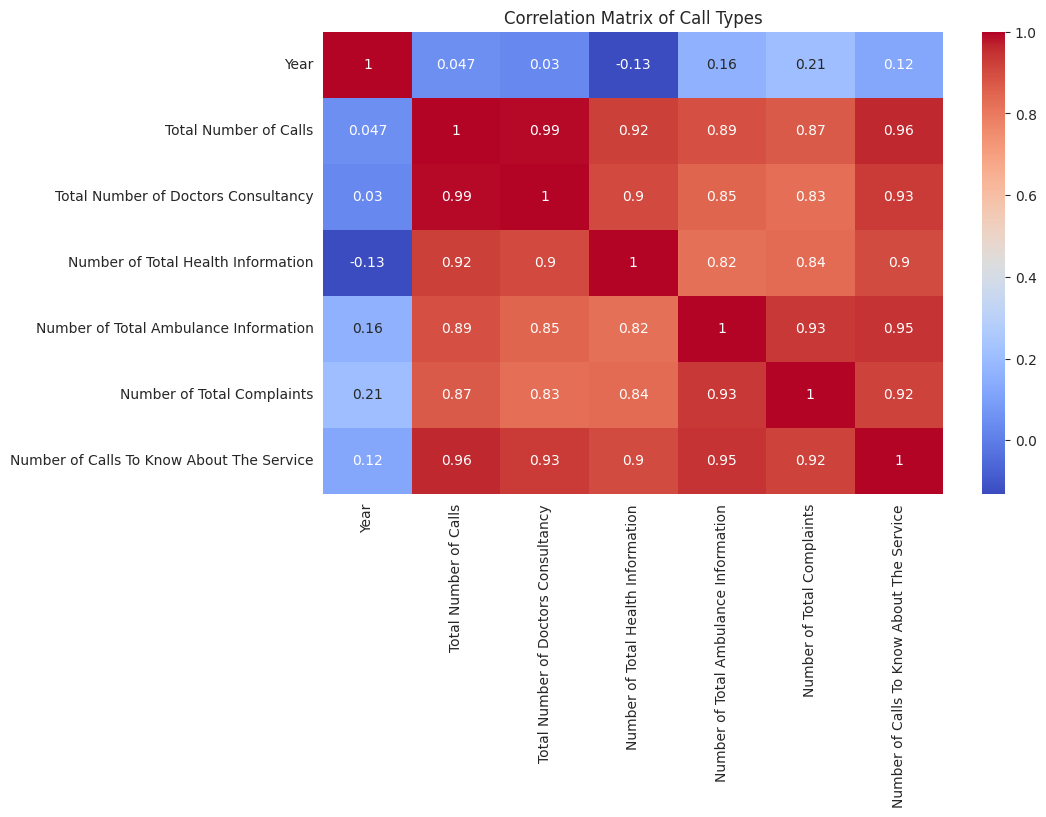

In [16]:
# Correlation Heatmap (excluding non-numeric columns)
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix of Call Types")
plt.show()

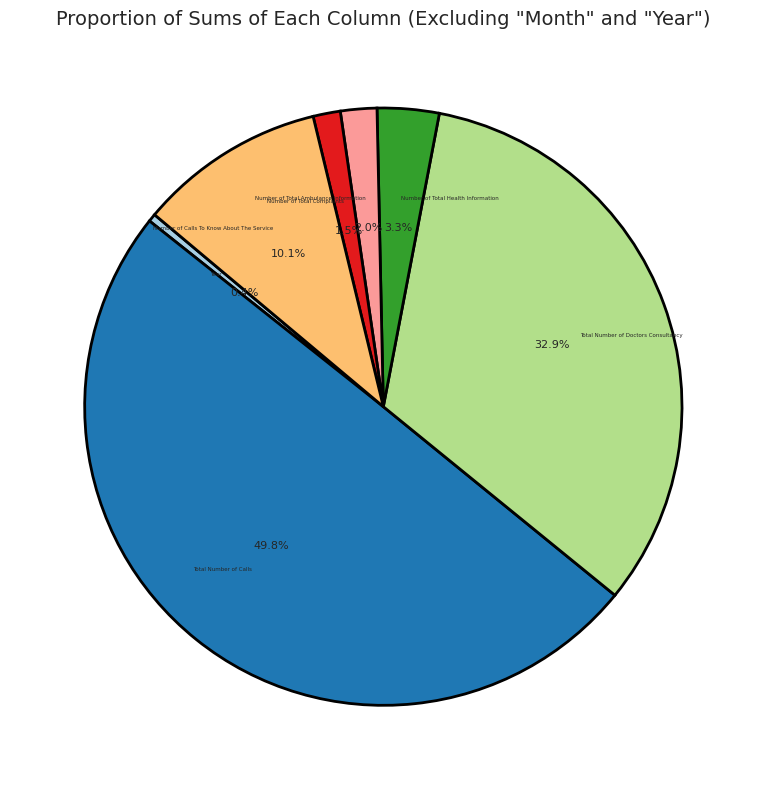

In [17]:
numeric_cols = df.select_dtypes(include=['number'])
sum_data = numeric_cols.sum()
plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    sum_data, 
    labels=sum_data.index, 
    autopct='%1.1f%%', 
    colors=plt.cm.Paired.colors, 
    startangle=140, 
    labeldistance=0.7,  
    textprops={'fontsize': 4},  
    wedgeprops={'linewidth': 2, 'edgecolor': 'black'}  
)

for autotext in autotexts:
    autotext.set_fontsize(8)
plt.title('Proportion of Sums of Each Column (Excluding "Month" and "Year")', fontsize=14)
plt.tight_layout()
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [19]:
data = pd.DataFrame({
    'Year': np.random.randint(2015, 2024, 500),
    'Month': np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 500),
    'Total Number of Calls': np.random.randint(100, 500, 500),
    'Total Number of Doctors Consultancy': np.random.randint(50, 200, 500),
    'Number of Total Health Information': np.random.randint(10, 100, 500),
    'Number of Total Ambulance Information': np.random.randint(5, 50, 500),
    'Number of Total Complaints': np.random.randint(1, 30, 500),
    'Number of Calls To Know About The Service': np.random.randint(1, 50, 500),
    'Target': np.random.choice([0, 1], 500)  # Example target variable
})

In [20]:
# Convert Year and Month into a single datetime feature
data['Month'] = data['Month'].astype(str)
data['Date'] = pd.to_datetime(data['Year'].astype(str) + '-' + data['Month'], errors='coerce')
data.drop(columns=['Year', 'Month'], inplace=True)

In [21]:
# Encode Date Feature
data['Date'] = data['Date'].astype('int64') // 10**9  # Convert to Unix timestamp

In [22]:
# Separate Features and Target
X = data.drop(columns=['Target'])
y = data['Target']

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
# Models Dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC()
}

In [26]:
# Train and Evaluate Models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

# Show Results
for model, acc in results.items():
    print(f"{model}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.5300
Decision Tree: Accuracy = 0.4700
Random Forest: Accuracy = 0.5600
Gradient Boosting: Accuracy = 0.5400
XGBoost: Accuracy = 0.5200
SVM: Accuracy = 0.4800


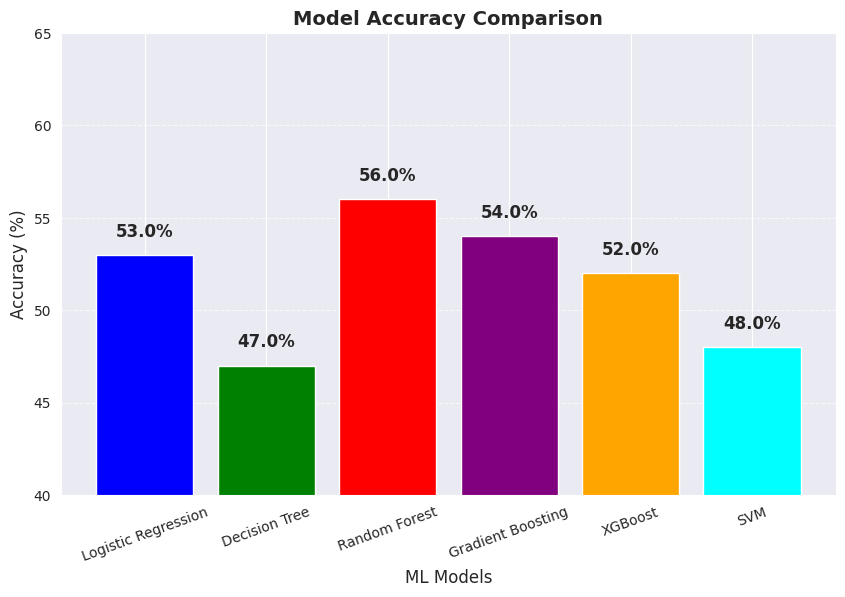

In [27]:
model_names = list(results.keys())
accuracies = [acc * 100 for acc in results.values()]

# Plot Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['blue', 'green', 'red', 'purple', 'orange', 'cyan'])

# Add text labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.1f}%", 
             ha='center', fontsize=12, fontweight='bold')

# Customize Plot
plt.ylim(40, 65)
plt.xlabel("ML Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show Plot
plt.show()

## Thank you...!!! Pls upvote!!!!